In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sbn

In [2]:
# Loading the cleaned dataset
df = pd.read_csv('../data/cleaned/netflix_cleaned.csv')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8784 entries, 0 to 8783
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8784 non-null   str  
 1   type          8784 non-null   str  
 2   title         8784 non-null   str  
 3   director      6198 non-null   str  
 4   country       8497 non-null   str  
 5   date_added    8784 non-null   str  
 6   release_year  8784 non-null   int64
 7   rating        8784 non-null   str  
 8   duration      8784 non-null   str  
 9   listed_in     8784 non-null   str  
dtypes: int64(1), str(9)
memory usage: 686.4 KB


In [3]:
# CSV format can't store dtype info — 'date_added' dtype reverts to text on every reload.
# Re-converting here since this notebook needs it as a real date type.
df['date_added'] = pd.to_datetime(df['date_added'])
df.info()   # confirm the conversion took

<class 'pandas.DataFrame'>
RangeIndex: 8784 entries, 0 to 8783
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       8784 non-null   str           
 1   type          8784 non-null   str           
 2   title         8784 non-null   str           
 3   director      6198 non-null   str           
 4   country       8497 non-null   str           
 5   date_added    8784 non-null   datetime64[us]
 6   release_year  8784 non-null   int64         
 7   rating        8784 non-null   str           
 8   duration      8784 non-null   str           
 9   listed_in     8784 non-null   str           
dtypes: datetime64[us](1), int64(1), str(8)
memory usage: 686.4 KB


In [4]:
content_counts = df['type'].value_counts()
print(content_counts)

type
Movie      6122
TV Show    2662
Name: count, dtype: int64


In [5]:
# Content Proportion
content_percent = df['type'].value_counts(normalize=True) *100
print(content_percent.round(1))

type
Movie      69.7
TV Show    30.3
Name: proportion, dtype: float64


Movies make up 69.7% and TV Shows 30.3% of the cleaned datase(8784 titles).

CONTENT TYPE ANALYSIS DASHBOARD:

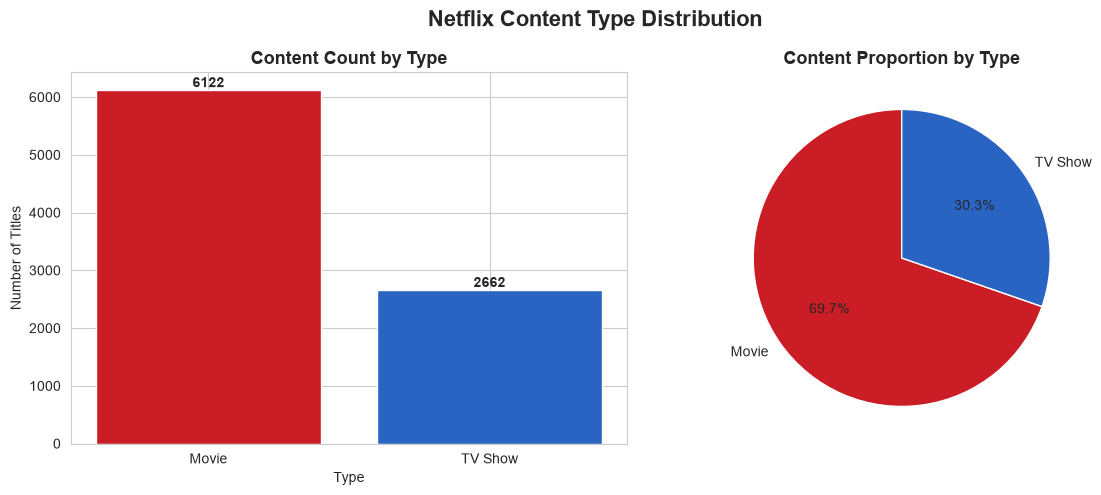

In [6]:
# Set a clean, consistent visual type for all charts in this notebook
sbn.set_style('whitegrid')
colors = ["#CB1D26", "#2a64c2"]  # Netflix red for Movie, blue for TV Show


# Create one figure with 1 row, 2 columns- two subplots side by side
fig, axes = plt.subplots(1,2, figsize=(12,5))

# --- Subplot 1: Bar chart (for precise comparison)---
axes[0].bar(content_counts.index, content_counts.values, color=colors)
axes[0].set_title('Content Count by Type', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Type')
axes[0].set_ylabel('Number of Titles')

for i, v in enumerate(content_counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')  # label each bar with its exact count

# --- Subplot 2: Pie chart (proportion at a glance)---
axes[1].pie(content_percent, labels=content_percent.index, autopct='%1.1f%%', colors=colors, startangle=90)
axes[1].set_title('Content Proportion by Type', fontsize=13, fontweight='bold')


# Overall Title for the whole dashboard figure
fig.suptitle("Netflix Content Type Distribution", fontsize=16, fontweight='bold')

plt.tight_layout()
plt.savefig('../screenshots/Task2_01.content_type_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

In [7]:
ratio = content_counts['Movie'] / content_counts['TV Show']
print(f"Movies outnumber TV Shows by a ratio of {ratio:.1f}:1")

Movies outnumber TV Shows by a ratio of 2.3:1


Movies outnumber TV Shows by roughly of 2.3:1 on Netflix, making up more than two-third of the titles

KEY FINDINGS:

- The dataset is movie-dominated: 69.7% of titles are Movies versus 30.3% TV Shows.
- Movies outnumber TV Shows by roughly 2.3:1.
- This split will be kept in mind for later tasks (e.g. country or rating analysis) — raw counts broken down by type will naturally skew toward Movies simply due to this base distribution, not necessarily a genuine trend in that dimension.